In [11]:
import pandahouse as ph

connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': '...',   # пароль скрыт
    'user': 'student',
    'database': 'simulator_20260920'
}

ph.read_clickhouse('SELECT count() FROM {db}.feed_actions', connection=connection)

,count()
0,40735592


# АА-тест: проверка системы сплитования

Проверяем, что пользователи корректно делятся на экспериментальные группы: при отсутствии воздействия статистический тест должен находить «различия» не чаще, чем в 5% случаев.

exp_group
2    8362
3    8425
Name: user_id, dtype: int64


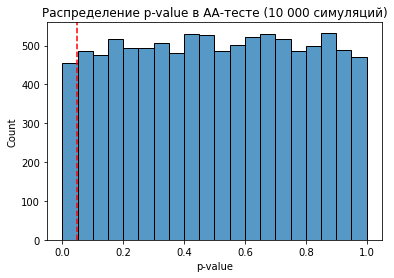

Доля p-value < 0.05: 0.0455


In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

q = """
SELECT exp_group,
       user_id,
       sum(action = 'like') AS likes,
       sum(action = 'view') AS views,
       likes / views AS ctr
FROM {db}.feed_actions
WHERE toDate(time) BETWEEN '2026-08-21' AND '2026-08-27'
  AND exp_group IN (2, 3)
GROUP BY exp_group, user_id
"""
df = ph.read_clickhouse(q, connection=connection)
print(df.groupby('exp_group').user_id.count())

ctr_2 = df.loc[df.exp_group == 2, 'ctr'].to_numpy()
ctr_3 = df.loc[df.exp_group == 3, 'ctr'].to_numpy()

rng = np.random.default_rng(42)
n_sim, n = 10_000, 500
p_values = np.empty(n_sim)

for i in range(n_sim):
    a = rng.choice(ctr_2, size=n, replace=False)
    b = rng.choice(ctr_3, size=n, replace=False)
    p_values[i] = stats.ttest_ind(a, b, equal_var=False).pvalue

sns.histplot(p_values, bins=20)
plt.axvline(0.05, color='red', linestyle='--')
plt.xlabel('p-value')
plt.title('Распределение p-value в АА-тесте (10 000 симуляций)')
plt.show()

print(f'Доля p-value < 0.05: {(p_values < 0.05).mean():.4f}')

Группы 0 (контроль) и 3 (тест)
  Общий CTR контроля: 0.2098
  t-тест по CTR:                    p = 6.22e-44
  t-тест по линеаризованным лайкам: p = 1.49e-58



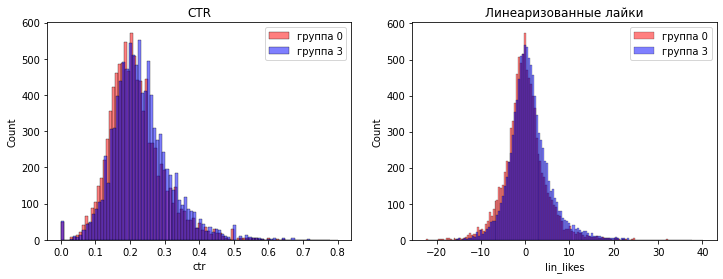

Группы 1 (контроль) и 2 (тест)
  Общий CTR контроля: 0.2096
  t-тест по CTR:                    p = 0.685
  t-тест по линеаризованным лайкам: p = 2.98e-09



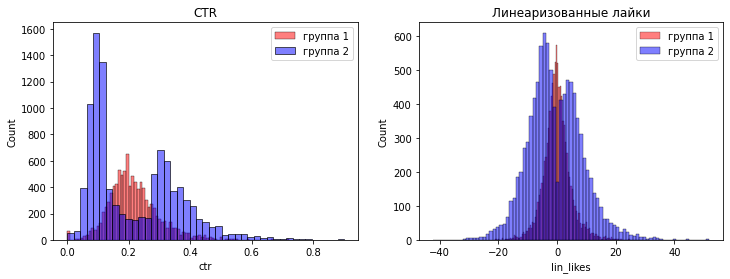

In [9]:
q = """
SELECT exp_group,
       user_id,
       sum(action = 'like') AS likes,
       sum(action = 'view') AS views,
       likes / views AS ctr
FROM {db}.feed_actions
WHERE toDate(time) BETWEEN '2026-08-28' AND '2026-09-03'
  AND exp_group IN (0, 1, 2, 3)
GROUP BY exp_group, user_id
"""
df_all = ph.read_clickhouse(q, connection=connection)

def linearized_test(df, control, test):
    c = df[df.exp_group == control].copy()
    t = df[df.exp_group == test].copy()

    ctr_control = c.likes.sum() / c.views.sum()
    c['lin_likes'] = c.likes - ctr_control * c.views
    t['lin_likes'] = t.likes - ctr_control * t.views

    p_ctr = stats.ttest_ind(c.ctr, t.ctr, equal_var=False).pvalue
    p_lin = stats.ttest_ind(c.lin_likes, t.lin_likes, equal_var=False).pvalue

    print(f'Группы {control} (контроль) и {test} (тест)')
    print(f'  Общий CTR контроля: {ctr_control:.4f}')
    print(f'  t-тест по CTR:                    p = {p_ctr:.3g}')
    print(f'  t-тест по линеаризованным лайкам: p = {p_lin:.3g}')
    print()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(c.ctr, color='r', alpha=0.5, label=f'группа {control}', ax=ax[0])
    sns.histplot(t.ctr, color='b', alpha=0.5, label=f'группа {test}', ax=ax[0])
    ax[0].set_title('CTR'); ax[0].legend()
    sns.histplot(c.lin_likes, color='r', alpha=0.5, label=f'группа {control}', ax=ax[1])
    sns.histplot(t.lin_likes, color='b', alpha=0.5, label=f'группа {test}', ax=ax[1])
    ax[1].set_title('Линеаризованные лайки'); ax[1].legend()
    plt.show()

linearized_test(df_all, 0, 3)
linearized_test(df_all, 1, 2)

In [ ]:
# Выводы по АА-тесту

**Цель:** проверить корректность системы сплитования перед запуском A/B-теста.

**Метод:** данные за 2026-08-21 - 2026-08-27, группы 2 и 3. Провели 10 000 симуляций: из каждой группы брали подвыборку в 500 пользователей без возвращения и сравнивали пользовательский CTR t-тестом Уэлча (equal_var=False).

**Результат:**
- Распределение p-value близко к равномерному, пика около нуля нет.
- Доля p-value ниже 0.05 составила 4.55%, что соответствует заданному уровню значимости 5% (отклонение в пределах случайного шума: стандартная ошибка доли при 10 000 симуляций около 0.2 п.п.).

**Вывод:** группы 2 и 3 статистически не различаются по CTR, доля ложноположительных срабатываний не превышает ожидаемую. Система сплитования работает корректно, на ней можно проводить A/B-тесты.